# Практическое задание 2: Предобработка данных и выделение признаков


датасет можно найти по ссылке на [kaggle](https://www.kaggle.com/datasets/ekibee/car-sales-information)

In [1]:
import pandas as pd
df = pd.read_csv('all_regions.csv')

In [2]:
df.columns

Index(['brand', 'name', 'bodyType', 'color', 'fuelType', 'year', 'mileage',
       'transmission', 'power', 'price', 'vehicleConfiguration', 'engineName',
       'engineDisplacement', 'date', 'location', 'link', 'description',
       'parse_date'],
      dtype='object')

Описание признаков:

1. **brand** — бренд автомобиля (например, Toyota, BMW, Лада).

2. **name** — модель автомобиля (например, Camry, X5, Vesta).

3. **bodyType** — тип кузова автомобиля (Хэтчбек 5 дв., Лифтбек, Джип 3 дв.,Седан)
    

4. **color** — цвет автомобиля:
    * Белый
    * Черный
    * Красный 
    * Серебристый
    * и другие варианты.

5. **fuelType** — тип топлива:
    * Бензин
    * Дизель
    * Электро

6. **year** — год выпуска автомобиля.

7. **mileage** — пробег автомобиля в километрах.

8. **transmission** — тип коробки передач:
    * Механика
    * АКПП
    * Вариатор
    * Автомат
    * Робот

9. **power** — мощность двигателя в лошадиных силах.

10. **price** — цена автомобиля (в рублях или другой валюте).

11. **vehicleConfiguration** — конфигурация автомобиля (комплектация, дополнительные опции).

12. **engineName** — название двигателя.

13. **engineDisplacement** — объем двигателя в литрах.

14. **date** — дата размещения объявления на сайте.

15. **location** — местоположение продавца (город, регион).

16. **link** — ссылка на объявление на сайте.

17. **description** — описание автомобиля, предоставленное продавцом.

18. **parse_date** — дата и время сбора данных (когда информация была загружена с сайта).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294757 entries, 0 to 1294756
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   brand                 1294757 non-null  object 
 1   name                  1294757 non-null  object 
 2   bodyType              1294757 non-null  object 
 3   color                 1257029 non-null  object 
 4   fuelType              1289815 non-null  object 
 5   year                  724644 non-null   float64
 6   mileage               771799 non-null   float64
 7   transmission          1289563 non-null  object 
 8   power                 1273353 non-null  float64
 9   price                 1294757 non-null  int64  
 10  vehicleConfiguration  724647 non-null   object 
 11  engineName            720976 non-null   object 
 12  engineDisplacement    717625 non-null   object 
 13  date                  1294757 non-null  object 
 14  location              1294757 non-

In [4]:
df.describe()

,year,mileage,power,price
count,724644.000000,771799.000000,1.273353e+06,1.294757e+06
mean,2009.684535,154893.397115,1.415560e+02,1.444358e+06
std,9.367108,100738.336936,6.563943e+01,1.970257e+06
min,1936.000000,1000.000000,1.000000e+00,2.700000e+02
25%,2003.000000,82000.000000,9.800000e+01,4.250000e+05
50%,2011.000000,144000.000000,1.280000e+02,8.700000e+05
75%,2017.000000,211000.000000,1.630000e+02,1.765000e+06
max,2023.000000,1000000.000000,1.000000e+03,1.500000e+08


In [5]:
df.head()

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,link,description,parse_date
0,Volkswagen,Golf,Хэтчбек 5 дв.,Серебристый,Бензин,NaN,240000.0,Механика,101.0,280000,NaN,NaN,NaN,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/volkswagen/golf/5001300...,101 л.с. люк не течёт. Документы в порядке. Со...,2023-05-02 01:00:00
1,Лада,1111 Ока,Хэтчбек 3 дв.,Фиолетовый,Бензин,1996.0,37000.0,Механика,33.0,95000,0.6 MT 11113,ВАЗ-11113,0.7 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/oka/50378140.html,"Ваз Ока Год: 2003 Цвет: Баклажан, в ПТС так и ...",2023-05-02 20:00:00
2,Toyota,Funcargo,Хэтчбек 5 дв.,Серебристый,Бензин,2002.0,295000.0,АКПП,87.0,380000,1.3 J,2NZ-FE,1.3 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/toyota/funcargo/5037751...,ХОРОШЕЕ СОСТОЯНИЕ. замена комплекта грм и помп...,2023-05-02 20:00:00
3,Лада,Гранта,Лифтбек,Серый,Бензин,2018.0,16000.0,Механика,106.0,795000,1.6 MT Comfort,ВАЗ-21127,1.6 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/granta/50382492.html,"Автомобиль в отличном техническом состоянии, н...",2023-05-02 23:00:00
4,Лада,Нива Легенд,Джип 3 дв.,Зеленый,Бензин,NaN,NaN,Механика,83.0,1022900,NaN,NaN,NaN,2023-04-02 00:00:00,Яблоновский,https://yablonovskiy.drom.ru/lada/niva_legend/...,Модель: Нива Легенд Комплектация: LADA (ВАЗ) N...,2023-05-02 20:00:00


In [6]:
df.shape

(1294757, 18)

In [7]:
df.sample(7)

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,link,description,parse_date
372531,Mercedes-Benz,CLA-Class,Седан,Черный,Бензин,2013.0,NaN,Робот,122.0,1515000,CLA 180 AMG Line,M 270 DE 16 AL red.,1.6 LTR,2023-06-14 00:00:00,Владивосток,https://vladivostok.drom.ru/mercedes-benz/cla-...,Свежий приход. Только с таможни. В отличном со...,2023-06-14 15:00:00
255981,Nissan,Juke,Джип 5 дв.,Серый,Бензин,2011.0,124000.0,Вариатор,117.0,987000,1.6 CVT 2WD SE+ Sport,HR16DE,1.6 LTR,2023-05-07 00:00:00,Красноярск,https://krasnoyarsk.drom.ru/nissan/juke/508276...,автомобиль приобретён у официального дилера Ни...,2023-05-08 17:00:00
1236280,Mercedes-Benz,E-Class,Седан,Черный,Бензин,NaN,39000.0,АКПП,197.0,3995000,NaN,NaN,NaN,2023-06-04 00:00:00,Санкт-Петербург,https://spb.drom.ru/mercedes-benz/e-class/5077...,Модель: E-Class Комплектация: E 200 4M (2.0TP/...,2023-06-04 16:00:00
1040324,Лада,2114 Самара,Хэтчбек 5 дв.,Зеленый,Бензин,2007.0,105000.0,Механика,81.0,160000,1.6 MT 21144-20-010,ВАЗ-11183,1.6 LTR,2023-04-28 00:00:00,Миасс,https://miass.drom.ru/lada/2114/50613531.html,"Продам ВАЗ 2114.в отличном состояние.целая ,не...",2023-05-01 23:00:00
952975,Nissan,Terrano,Джип 5 дв.,Серый,Бензин,2014.0,NaN,Механика,102.0,795000,1.6 MT Comfort,K4M,1.6 LTR,2023-06-07 00:00:00,Екатеринбург,https://ekaterinburg.drom.ru/nissan/terrano/47...,"TЕХНИЧЕСКАЯ ГАРАНТИЯ НА 1 ГОД ОТ ООО ""Karso"" N...",2023-06-08 08:00:00
341386,Toyota,Roomy,Хэтчбек 5 дв.,Серебристый,Бензин,2018.0,74000.0,Вариатор,69.0,695000,1.0 X S,1KR-FE,1.0 LTR,2023-05-30 00:00:00,Уссурийск,https://ussuriisk.drom.ru/toyota/roomy/5088461...,ТОЛЬКО С ТАМОЖНИ КНОПКА СТАРТ ИММОБИЛАЙЗЕР ЭЛЕ...,2023-05-30 20:00:00
362192,Toyota,Succeed,Универсал,NaN,Бензин,NaN,NaN,Вариатор,74.0,1020000,NaN,NaN,NaN,2023-06-10 00:00:00,Владивосток,https://vladivostok.drom.ru/toyota/succeed/512...,NaN,2023-06-10 19:00:00


In [8]:
df.duplicated().sum()

0

In [9]:
df.isnull().sum()

brand                        0
name                         0
bodyType                     0
color                    37728
fuelType                  4942
year                    570113
mileage                 522958
transmission              5194
power                    21404
price                        0
vehicleConfiguration    570110
engineName              573781
engineDisplacement      577132
date                         0
location                     0
link                         0
description              40352
parse_date                   0
dtype: int64

<Axes: >

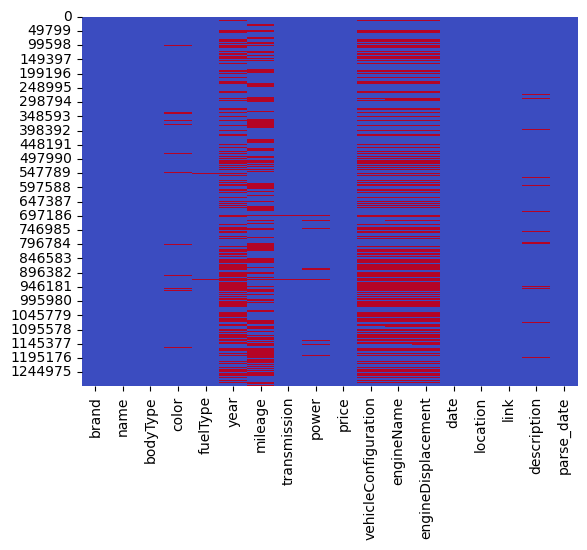

In [10]:
import seaborn as sns

sns.heatmap(df.isnull(),cbar=False, cmap='coolwarm')

In [11]:
(df.isna().sum()/len(df)) * 100

brand                    0.000000
name                     0.000000
bodyType                 0.000000
color                    2.913906
fuelType                 0.381693
year                    44.032432
mileage                 40.390436
transmission             0.401156
power                    1.653129
price                    0.000000
vehicleConfiguration    44.032201
engineName              44.315729
engineDisplacement      44.574542
date                     0.000000
location                 0.000000
link                     0.000000
description              3.116569
parse_date               0.000000
dtype: float64

In [12]:
df = df.dropna() 

In [13]:
df = df[(df['price'] >= 30000) & (df['price'] <= 7000000)]

In [14]:
(df.isna().sum()/len(df)) * 100

brand                   0.0
name                    0.0
bodyType                0.0
color                   0.0
fuelType                0.0
year                    0.0
mileage                 0.0
transmission            0.0
power                   0.0
price                   0.0
vehicleConfiguration    0.0
engineName              0.0
engineDisplacement      0.0
date                    0.0
location                0.0
link                    0.0
description             0.0
parse_date              0.0
dtype: float64

In [15]:
df.value_counts('brand')

brand
Toyota         108731
Лада            48220
Honda           34332
Nissan          32389
Kia             14582
                ...  
Barkas              1
Tank                1
Rolls-Royce         1
Maxus               1
Mitsuoka            1
Name: count, Length: 103, dtype: int64

In [16]:
# Топ-5 брендов
top_brands = df['brand'].value_counts().head(5).index.tolist()

# Топ модели по каждому бренду
top_models = (
    df[df['brand'].isin(top_brands)]
    .groupby(['brand', 'name'])
    .size()
    .reset_index(name='count')
    .sort_values(['brand', 'count'], ascending=[True, False])
    .groupby('brand')
    .head(5)
)

print(top_models)

      brand                name  count
24    Honda                 Fit   5511
27    Honda               Freed   3538
0     Honda              Accord   2970
68    Honda               Vezel   2694
7     Honda                CR-V   2265
95      Kia                 Rio   3721
103     Kia            Sportage   2125
100     Kia             Sorento   1453
76      Kia                Ceed   1388
77      Kia              Cerato    973
175  Nissan                Note   4861
218  Nissan             X-Trail   3176
189  Nissan             Qashqai   2031
208  Nissan               Teana   1724
198  Nissan              Serena   1322
239  Toyota               Camry   7821
250  Toyota             Corolla   5996
256  Toyota     Corolla Fielder   5737
299  Toyota  Land Cruiser Prado   5272
327  Toyota               Prius   4985
406    Лада         2114 Самара   5122
429    Лада              Приора   5122
416    Лада              Гранта   4445
402    Лада                2110   4106
404    Лада              

In [17]:


names = ['CR-V', 'Accord', 'Camry', 'RAV4', 'X-Trail', 'Teana']

df = (
    df[df['name'].isin(names)]
    .groupby('name', group_keys=False)
    .apply(lambda x: x.sample(n=1700, random_state=42))
    .reset_index(drop=True)
)

print(df['name'].value_counts())
print(df.shape)


name
Accord     1700
CR-V       1700
Camry      1700
RAV4       1700
Teana      1700
X-Trail    1700
Name: count, dtype: int64
(10200, 18)


C:\Users\igor\AppData\Local\Temp\ipykernel_5776\1518077167.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=1700, random_state=42))


In [18]:
df['engineDisplacement'] = df['engineDisplacement'].str.extract(r'([\d.]+)').astype(float) 
# [\d.] класс символов: цифра (\d) или точка (.) 
#  +  один или более таких символов подряд
# ( ) группа захвата — именно это extract возвращает

In [19]:
import numpy as np

def estimate_displacement(row):
    if pd.isna(row['engineDisplacement']) and pd.notna(row['power']):
        fuel = row['fuelType']
        hp = row['power']
        
        if fuel == 'Электро':
            return round(hp / 65, 1) 
        elif fuel == 'Дизель':
            return round(hp / 70, 1)
        else:  
            return round(hp / 60, 1)
    
    return row['engineDisplacement']  

df['engineDisplacement'] = df.apply(estimate_displacement, axis=1)

In [20]:
#df[df['year'] >= 2021][['year', 'mileage']].sample(7)

In [21]:
df['year'] = df['year'].astype(int)

# считаем среднее по каждому году из существующих данных
year_mean_mileage = df.groupby('year')['mileage'].median()

# заполняем пропуски средним по году
mask = df['mileage'].isna()
df.loc[mask, 'mileage'] = df.loc[mask, 'year'].map(year_mean_mileage)


In [22]:
#df = df.dropna(subset=['mileage'])
year_mean_mileage

year
1983    181000.0
1985    347500.0
1986    299000.0
1987    300000.0
1988    245000.0
1989    303000.0
1990    303000.0
1991    289000.0
1992    320000.0
1993    259000.0
1994    296000.0
1995    268000.0
1996    275000.0
1997    257000.0
1998    280000.0
1999    251000.0
2000    250000.0
2001    242500.0
2002    257000.0
2003    248000.0
2004    239000.0
2005    246000.0
2006    230000.0
2007    208000.0
2008    216000.0
2009    201000.0
2010    187500.0
2011    180000.0
2012    146000.0
2013    145000.0
2014    142000.0
2015    108500.0
2016     91000.0
2017     76000.0
2018     57500.0
2019     37000.0
2020     28000.0
2021     19000.0
2022     12000.0
Name: mileage, dtype: float64

In [23]:

df.shape

(10200, 18)

In [24]:
df = df.dropna(subset=['color'])
df = df.dropna(subset=['description'])
df = df.dropna(subset=['engineName'])
df = df.dropna(subset=['fuelType'])
df = df.dropna(subset=['mileage'])

In [25]:
(df.isna().sum()/len(df)) * 100

brand                   0.0
name                    0.0
bodyType                0.0
color                   0.0
fuelType                0.0
year                    0.0
mileage                 0.0
transmission            0.0
power                   0.0
price                   0.0
vehicleConfiguration    0.0
engineName              0.0
engineDisplacement      0.0
date                    0.0
location                0.0
link                    0.0
description             0.0
parse_date              0.0
dtype: float64

In [26]:
len(df['engineName'].sort_values().unique())

106

In [27]:
df.value_counts('brand') # 

brand
Honda     3400
Nissan    3400
Toyota    3400
Name: count, dtype: int64

In [28]:

from datetime import datetime
df['date'] = pd.to_datetime(df['date'])
current_year = df['date'].max().year
df['years_in_service'] = current_year - df['year']


In [29]:
df[['power', 'price']].describe()

,power,price
count,10200.000000,1.020000e+04
mean,166.973529,1.293132e+06
std,28.489803,8.558507e+05
min,85.000000,3.800000e+04
25%,147.000000,6.500000e+05
50%,167.000000,1.050000e+06
75%,181.000000,1.725000e+06
max,281.000000,4.999999e+06


In [30]:
df[['price']].sort_values(by='price', ascending=False)

,price
4512,4999999
6559,4990000
4249,4900000
4686,4900000
4430,4850000
...,...
4583,51000
1069,45000
379,45000
1645,40000


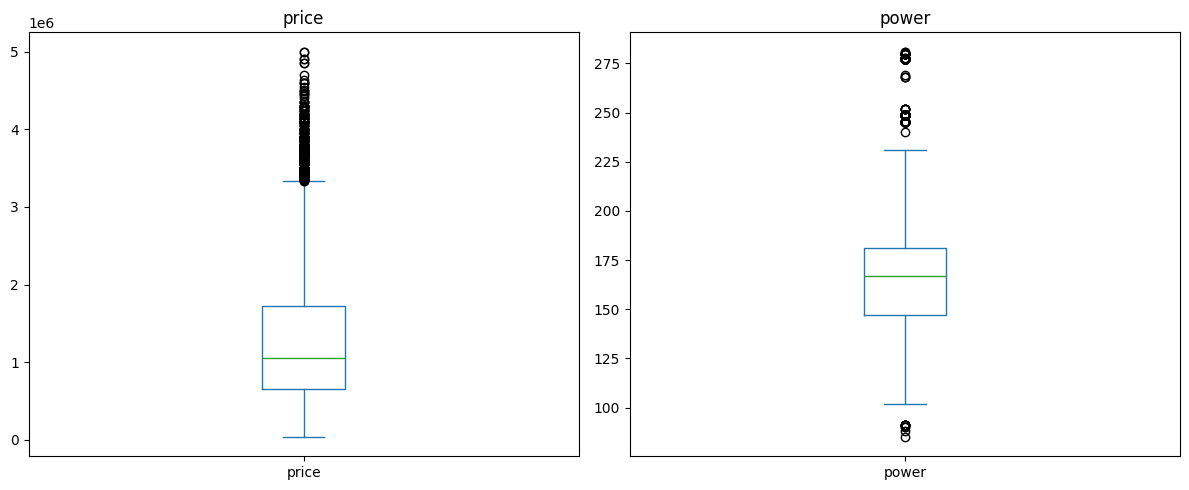

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['price'].plot(kind='box', ax=axes[0], title='price')
df['power'].plot(kind='box', ax=axes[1], title='power')

plt.tight_layout()
plt.show()

In [32]:
df = df[(df['price'] >= 30000) & (df['price'] <= 70000000)]

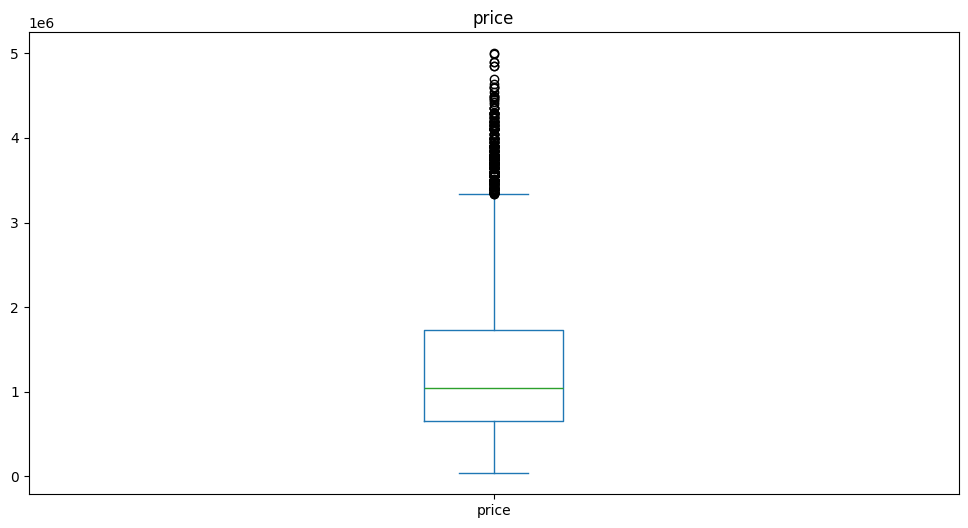

In [33]:
plt.figure(figsize=(12,6))
df['price'].plot(kind='box', title='price')
plt.show()

In [34]:
df['price'].mean()

1293132.2024509804

In [35]:
df[df['price'] == 10000000]

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,link,description,parse_date,years_in_service


In [36]:
from sklearn.preprocessing import LabelEncoder

# (много уникальных значений, используем LE чтобы не раздувать датасет)
le = LabelEncoder()
for col in ['location', 'color', 'engineName', 'vehicleConfiguration']:
    df[col] = le.fit_transform(df[col].astype(str))

# (мало уникальных значений, нет порядка между категориями)
df = pd.get_dummies(df, columns=['name', 'brand', 'fuelType', 'bodyType', 'transmission'], dtype=int, drop_first=True)

In [37]:
# 1. (интенсивность использования)
df['mileage_per_year'] = (df['mileage'] / df['years_in_service'].replace(0, 1)).round(0)

# 2. (удельная мощность двигателя)
df['power_per_liter'] = (df['power'] / df['engineDisplacement']).round(1)


In [38]:
positive_keywords = [
    # состояние
    'хорошее состояние', 'отличное состояние', 'идеальное состояние',
    'не гнилой', 'гнили нет', 'без гнили',
    # ремонт и замена
    'замена', 'новое', 'новый', 'новая', 'после капиталки', 'капремонт',
    'заменен', 'заменена', 'заменены',
    # детали
    'грм', 'помпа', 'сцепление', 'колодки', 'стойки', 'подшипники',
    'резина', 'масла поменяны',
    # двигатель
    'двигатель тянет', 'не воет', 'раздатка не воет',
    # документы
    'один владелец', '1 владелец', 'оригинал птс',
]

negative_keywords = [
    # состояние
    'битый', 'крашеный', 'после дтп', 'не на ходу', 'требует ремонта',
    'есть проблемы', 'небольшие проблемы',
    # кузов
    'ржавчина', 'гниль', 'коррозия', 'вмятина', 'царапина',
    # двигатель
    'троит', 'дымит', 'течет масло', 'стук', 'расход масла',
    # документы
    'без птс', 'утилизация', 'в залоге',
    # возраст
     'старый'
]


def estimate_condition(text):
    
    text = text.lower()
    score = 0  # базовая оценка
    
    for word in positive_keywords:
        if word in text:
            score += 0.3
    
    for word in negative_keywords:
        if word in text:
            score -= 0.4

    return round(score, 1)

df['condition_score'] = df['description'].apply(estimate_condition)

print(df['condition_score'].describe())

count    10200.000000
mean         0.242225
std          0.402510
min         -1.300000
25%          0.000000
50%          0.000000
75%          0.300000
max          2.600000
Name: condition_score, dtype: float64


In [39]:
df.sample(7)

,color,year,mileage,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,...,bodyType_Джип 5 дв.,bodyType_Купе,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 5 дв.,transmission_Вариатор,transmission_Механика,mileage_per_year,power_per_liter,condition_score
4057,14,2006,340000.0,277.0,719000,750,14,3.5,2023-06-02,96,...,0,0,1,0,0,0,0,20000.0,79.1,0.3
6412,1,2013,175000.0,146.0,1750000,185,21,2.0,2023-05-27,242,...,1,0,0,0,0,1,0,17500.0,73.0,0.0
3572,14,2002,270000.0,186.0,575000,741,3,3.0,2023-05-04,231,...,0,0,1,0,0,0,0,12857.0,62.0,0.0
9536,14,2015,188000.0,171.0,1620000,668,94,2.5,2023-05-09,211,...,1,0,0,0,0,1,0,23500.0,68.4,0.3
5048,10,2006,326000.0,167.0,840000,507,11,2.4,2023-06-03,181,...,0,0,1,0,0,0,0,19176.0,69.6,-0.5
7301,14,2008,172000.0,249.0,830000,760,104,3.5,2023-06-03,60,...,0,0,1,0,0,1,0,11467.0,71.1,0.9
1238,11,2008,287000.0,201.0,920000,492,76,2.4,2023-05-27,549,...,0,0,1,0,0,0,0,19133.0,83.8,0.3


In [40]:
columns_to_drop = [
    'link', 
    'date', 
    'parse_date', 
    'description', 
    'years_in_service', # Дубликат year
    'engineName',       
    'location',         
    'color',            
    'vehicleConfiguration'
    
    
]

# Удаляем колонки из датафрейма df
df = df.drop(columns=columns_to_drop)

# Проверяем результат
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    10200 non-null  int32  
 1   mileage                 10200 non-null  float64
 2   power                   10200 non-null  float64
 3   price                   10200 non-null  int64  
 4   engineDisplacement      10200 non-null  float64
 5   name_CR-V               10200 non-null  int32  
 6   name_Camry              10200 non-null  int32  
 7   name_RAV4               10200 non-null  int32  
 8   name_Teana              10200 non-null  int32  
 9   name_X-Trail            10200 non-null  int32  
 10  brand_Nissan            10200 non-null  int32  
 11  brand_Toyota            10200 non-null  int32  
 12  fuelType_Дизель         10200 non-null  int32  
 13  bodyType_Джип 5 дв.     10200 non-null  int32  
 14  bodyType_Купе           10200 non-null

In [41]:
df.to_csv('df_filtered_drom.csv', index=False)

In [42]:
df.columns

Index(['year', 'mileage', 'power', 'price', 'engineDisplacement', 'name_CR-V',
       'name_Camry', 'name_RAV4', 'name_Teana', 'name_X-Trail', 'brand_Nissan',
       'brand_Toyota', 'fuelType_Дизель', 'bodyType_Джип 5 дв.',
       'bodyType_Купе', 'bodyType_Седан', 'bodyType_Универсал',
       'bodyType_Хэтчбек 5 дв.', 'transmission_Вариатор',
       'transmission_Механика', 'mileage_per_year', 'power_per_liter',
       'condition_score'],
      dtype='object')

In [43]:
df.shape

(10200, 23)

In [44]:
df_filt = pd.read_csv('df_filtered_drom.csv')

In [45]:
df_filt.columns

Index(['year', 'mileage', 'power', 'price', 'engineDisplacement', 'name_CR-V',
       'name_Camry', 'name_RAV4', 'name_Teana', 'name_X-Trail', 'brand_Nissan',
       'brand_Toyota', 'fuelType_Дизель', 'bodyType_Джип 5 дв.',
       'bodyType_Купе', 'bodyType_Седан', 'bodyType_Универсал',
       'bodyType_Хэтчбек 5 дв.', 'transmission_Вариатор',
       'transmission_Механика', 'mileage_per_year', 'power_per_liter',
       'condition_score'],
      dtype='object')

In [46]:
df_filt.value_counts('brand_Nissan')

brand_Nissan
0    6800
1    3400
Name: count, dtype: int64

In [47]:
df_filt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    10200 non-null  int64  
 1   mileage                 10200 non-null  float64
 2   power                   10200 non-null  float64
 3   price                   10200 non-null  int64  
 4   engineDisplacement      10200 non-null  float64
 5   name_CR-V               10200 non-null  int64  
 6   name_Camry              10200 non-null  int64  
 7   name_RAV4               10200 non-null  int64  
 8   name_Teana              10200 non-null  int64  
 9   name_X-Trail            10200 non-null  int64  
 10  brand_Nissan            10200 non-null  int64  
 11  brand_Toyota            10200 non-null  int64  
 12  fuelType_Дизель         10200 non-null  int64  
 13  bodyType_Джип 5 дв.     10200 non-null  int64  
 14  bodyType_Купе           10200 non-null